### 3c. Parse and Insert: Change of Mind triggered animal trajectory and hippocampus decode

In [77]:
%reload_ext autoreload
%autoreload 2

[16:19:18][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:19:18][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [78]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
import copy
from spyglass.shijiegu.changeOfMind_triggered_position import find_triggered_animal_save

In [102]:
success = {}

In [80]:
# segment only (each arm got base substracted)
params_pre = {
          "proportion":0.1,
          "delta_t_minus":5,
          "delta_t_plus":0,
          "segment_only":True,
          "max_flag": 0,
          "control":False,
            "multiple_CoM":True, "single_CoM":True, "first_CoM":True}

params_pre_control = copy.deepcopy(params_pre)
params_pre_control["control"] = True

params_post = {
          "proportion":0.1,
          "delta_t_minus":0,
          "delta_t_plus":2,
          "segment_only":True,
          "max_flag": 0,
          "control":False,
          "multiple_CoM":True, "single_CoM":True, "first_CoM":True}

params_post_control = copy.deepcopy(params_post)
params_post_control["control"] = True

# absolute position
params_pre_abs = {
          "proportion":0.1,
          "delta_t_minus":5,
          "delta_t_plus":0,
          "segment_only":False,
          "max_flag": 0,
          "control":False,
          "multiple_CoM":True, "single_CoM":True, "first_CoM":True}

params_pre_abs_control = copy.deepcopy(params_pre_abs)
params_pre_abs_control["control"] = True


# absolute position
params_both_abs = {
          "proportion":0.1,
          "delta_t_minus":5,
          "delta_t_plus":5,
          "segment_only":False,
          "max_flag": 0,
          "control":False,
          "multiple_CoM":True, "single_CoM":True,
          "first_CoM":False}

params_both_abs_control = copy.deepcopy(params_both_abs)
params_both_abs_control["control"] = True

params_both_max = {
          "proportion":0.1,
          "delta_t_minus":5,
          "delta_t_plus":5,
          "segment_only":False,
          "max_flag": 1,
          "control":False,
          "multiple_CoM":True, "single_CoM":True, "first_CoM":False}


params_both_max_control = copy.deepcopy(params_both_max)
params_both_max_control["control"] = True


params_both_max_all = {"proportion":0.1, "delta_t_minus":5, "delta_t_plus":5, "max_flag":1,"control":False,
             "segment_only":True, "multiple_CoM":True, "single_CoM":True, "first_CoM":False} # all trials all change of minds
params_both_max_all_control = copy.deepcopy(params_both_max_all)
params_both_max_all_control["control"] = True

params = {"params_pre": params_pre, "params_pre_control":params_pre_control,
         "params_post":params_post, "params_post_control":params_post_control,
         "params_pre_abs":params_pre_abs, "params_pre_abs_control":params_pre_abs_control,
         "params_both_abs":params_both_abs, "params_both_abs_control":params_both_abs_control,
         "params_both_max":params_both_max, "params_both_max_control": params_both_max_control,
         "params_both_max_all":params_both_max_all, "params_both_max_all_control":params_both_max_all_control}


In [112]:
animal = 'Molly'
dates_to_plot = ['20220415','20220416','20220417','20220418','20220419','20220420']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

success[animal] = {}
for p in params:
    param = params[p]
    success[animal][p] = find_triggered_animal_save(animal, dates_to_plot, encoding_set, classifier_param_name, **param)

[2025-11-04 09:34:02,253][WARNING]: Reconnecting to MySQL server.
[09:34:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-04 09:34:02,339][WARNING]: Skipped checksum for file with hash: 8a103ed9-5ff0-a3ed-ecd9-ccd8313968f3, and path: /stelmo/nwb/analysis/molly20220418_KKKVHRSOC3.nwb
[2025-11-04 09:34:02,354][WARNING]: Skipped checksum for file with hash: 2bc3869e-8c0d-1ac5-8b3a-1056f2e552cc, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_ICI7K1NSNF.nwb
[2025-11-04 09:34:02,375][WARNING]: Skipped checksum for file with hash: 8a103ed9-5ff0-a3ed-ecd9-ccd8313968f3, and path: /stelmo/nwb/analysis/molly20220418_KKKVHRSOC3.nwb
[2025-11-04 09:34:02,382][WARNING]: Skipped checksum for file w

currently investigating:
02_Seq2Session1
pos 1 valid times
ERROR! Session/line number was not unique in database. History logging moved to new session 3410


[2025-11-04 09:34:02,613][WARNING]: Skipped checksum for file with hash: 49e174e6-983a-3a74-617c-a0b60ad29cc3, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_T981YFNE8N.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/ripple_detection/core.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_start_time = (~series.shift(1).fillna(False)) & series
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/ripple_detection/core.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_end_time = series & (~series

len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
rowID [39 44 48 58 70 74 80]


[09:34:12][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-04 09:34:12,186][WARNING]: Skipped checksum for file with hash: 2e5776f8-1207-f4b9-5d4c-afb472676892, and path: /stelmo/nwb/analysis/molly20220418_L0IDNB574Z.nwb
[2025-11-04 09:34:12,200][WARNING]: Skipped checksum for file with hash: eb86f8d0-e105-badf-4df3-22a09fe666bb, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_5C20VN3FQN.nwb
[2025-11-04 09:34:12,220][WARNING]: Skipped checksum for file with hash: 2e5776f8-1207-f4b9-5d4c-afb472676892, and path: /stelmo/nwb/analysis/molly20220418_L0IDNB574Z.nwb
[2025-11-04 09:34:12,226][WARNING]: Skipped checksum for file with hash: 2e5776f8-1207-f4b9-5d4c-afb472676892, and path: /stelmo/

...

len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
rowID [ 9 11 14 17 21 32 53 54 65]
nearby rowID [6, 13, 16, 16, 22, 29, 56, 56, 63]
nearby turnaround_times [[1650320276.7829442], [1650320461.7194607], [1650320531.8696566], [1650320531.8696566], [1650320649.7649863], [1650320783.7113605], [1650321421.1451414], [1650321421.1451414], [1650321606.9166603]]


[09:43:52][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-11-04 09:43:52,164][WARNING]: Skipped checksum for file with hash: 6139f388-e6c5-bf42-221e-672ceb8a1dd3, and path: /stelmo/nwb/analysis/molly20220418_DGFB07I19D.nwb
[2025-11-04 09:43:52,183][WARNING]: Skipped checksum for file with hash: 6ce0f9f0-cf63-9175-8f8e-b59d0e060c3d, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_B76N8DUOIF.nwb
[2025-11-04 09:43:52,208][WARNING]: Skipped checksum for file with hash: 6139f388-e6c5-bf42-221e-672ceb8a1dd3, and path: /stelmo/nwb/analysis/molly20220418_DGFB07I19D.nwb
[2025-11-04 09:43:52,216][WARNING]: Skipped checksum for file with hash: 6139f388-e6c5-bf42-221e-672ceb8a1dd3, and path: /stelmo/

currently investigating:
10_Seq2Session5
pos 9 valid times


[2025-11-04 09:43:52,378][WARNING]: Skipped checksum for file with hash: 9d79be6a-3320-c787-c2bf-3e43bec6fef5, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_K4WONOKV5E.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/ripple_detection/core.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_start_time = (~series.shift(1).fillna(False)) & series
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/ripple_detection/core.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  is_end_time = series & (~series

len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
len(subset_linear)  501
rowID [13 17 18 22 28 34 39 42 49 68]
nearby rowID [16, 16, 19, 19, 25, 31, 38, 45, 50, 67]
nearby turnaround_times [[1650324928.0556629], [1650324928.0556629], [1650324989.911832], [1650324989.911832], [1650325122.544195], [1650325243.7705266], [1650325445.4400783], [1650325609.6155272], [1650325724.5168417], [1650326173.6230698]]
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220418_p0.1_tm5_tp5_maxflag1_multiple_CoM1_single_CoM1_first_CoM0_control1.pkl


In [101]:
#%debug

In [113]:
success

{'Molly': {'params_pre': 1,
  'params_pre_control': 1,
  'params_post': 1,
  'params_post_control': 1,
  'params_pre_abs': 1,
  'params_pre_abs_control': 1,
  'params_both_abs': 1,
  'params_both_abs_control': 1,
  'params_both_max': 1,
  'params_both_max_control': 1,
  'params_both_max_all': 1,
  'params_both_max_all_control': 1},
 'Lewis': {'params_pre': 1,
  'params_pre_control': 1,
  'params_post': 1,
  'params_post_control': 1,
  'params_pre_abs': 1,
  'params_pre_abs_control': 1,
  'params_both_abs': 1,
  'params_both_abs_control': 1,
  'params_both_max': 1,
  'params_both_max_control': 1,
  'params_both_max_all': 1,
  'params_both_max_all_control': 1},
 'Eliot': {'params_pre': 1,
  'params_pre_control': 1,
  'params_post': 1,
  'params_post_control': 1,
  'params_pre_abs': 1,
  'params_pre_abs_control': 1,
  'params_both_abs': 1,
  'params_both_abs_control': 1,
  'params_both_max': 1,
  'params_both_max_control': 1,
  'params_both_max_all': 1,
  'params_both_max_all_control': 1}

In [ ]:
animal = 'Lewis'
dates_to_plot = ['20240104','20240105','20240106','20240107','20240108','20240109','20240110','20240113','20240114']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

success[animal] = {}
for p in params:
    param = params[p]
    success[animal][p] = find_triggered_animal_save(animal, dates_to_plot, encoding_set, classifier_param_name, **param)

In [ ]:
animal = 'Eliot'
#dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

success[animal] = {}
for p in params:
    param = params[p]
    success[animal][p] = find_triggered_animal_save(animal, dates_to_plot, encoding_set, classifier_param_name, **param)

In [ ]:
animal = 'Klein'
dates_to_plot = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']
encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'


success[animal] = {}
for p in params:
    param = params[p]
    success[animal][p] = find_triggered_animal_save(animal, dates_to_plot, encoding_set, classifier_param_name, **param)

In [ ]:
animal = 'Julio'
dates_to_plot = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'


success[animal] = {}
for p in params:
    param = params[p]
    success[animal][p] = find_triggered_animal_save(animal, dates_to_plot, encoding_set, classifier_param_name, **param)

In [111]:
success

[15:42:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:42:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:42:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:42:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackG

{'Molly': {'params_pre': 1,
  'params_pre_control': 1,
  'params_post': 1,
  'params_post_control': 1,
  'params_pre_abs': 1,
  'params_pre_abs_control': 1,
  'params_both_abs': 1,
  'params_both_abs_control': 1,
  'params_both_max': 1,
  'params_both_max_control': 1,
  'params_both_max_all': 1,
  'params_both_max_all_control': 1},
 'Lewis': {'params_pre': 1,
  'params_pre_control': 1,
  'params_post': 1,
  'params_post_control': 1,
  'params_pre_abs': 1,
  'params_pre_abs_control': 1,
  'params_both_abs': 1,
  'params_both_abs_control': 1,
  'params_both_max': 1,
  'params_both_max_control': 1,
  'params_both_max_all': 1,
  'params_both_max_all_control': 1},
 'Eliot': {'params_pre': 1,
  'params_pre_control': 1,
  'params_post': 1,
  'params_post_control': 1,
  'params_pre_abs': 1,
  'params_pre_abs_control': 1,
  'params_both_abs': 1,
  'params_both_abs_control': 1,
  'params_both_max': 1,
  'params_both_max_control': 1,
  'params_both_max_all': 1,
  'params_both_max_all_control': 1}

In [51]:
param

{'proportion': 0.1,
 'delta_t_minus': 5,
 'delta_t_plus': 5,
 'segment_only': False,
 'max_flag': 1,
 'control': False,
 'multiple_CoM': True,
 'single_CoM': True,
 'first_CoM': False}

In [22]:
%debug

> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/changeOfMind_triggered.py(139)turnaround_triggered_position()
    137             return None, None, None
    138         #assert 1 == 0
--> 139         # pick the longer duration
    140         interval_flag = np.argwhere([True if interval[0]<=t and interval[1]>=t else False for interval in intervals]).ravel()
    141         interval = intervals[int(interval_flag)]



ipdb>  exit


In [ ]:
animal = 'Haydn'
dates_to_plot = ['20230606']
encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4arm'

success[animal] = {}
for p in params:
    param = params[p]
    success[animal][p] = find_triggered_animal_save(animal, dates_to_plot, encoding_set, classifier_param_name, **param)

In [47]:
success

{'Molly': {'params_both_max': 1, 'params_both_max_control': 1},
 'Lewis': {'params_both_max': 1,
  'params_both_max_control': 1,
  'params_both_max_all': 1,
  'params_both_max_all_control': 1},
 'Eliot': {'params_both_max': 1,
  'params_both_max_control': 1,
  'params_both_max_all': 1,
  'params_both_max_all_control': 1},
 'Klein': {'params_both_max': 1,
  'params_both_max_control': 1,
  'params_both_max_all': 1,
  'params_both_max_all_control': 1},
 'Julio': {'params_both_max': 1,
  'params_both_max_control': 1,
  'params_both_max_all': 1,
  'params_both_max_all_control': 1}}

## End here

In [4]:
from spyglass.shijiegu.changeOfMind_triggered import (find_triggered_animal,
    plot_physical_vs_mental_position, parse_to_transitions)

[15:37:05][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:37:05][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


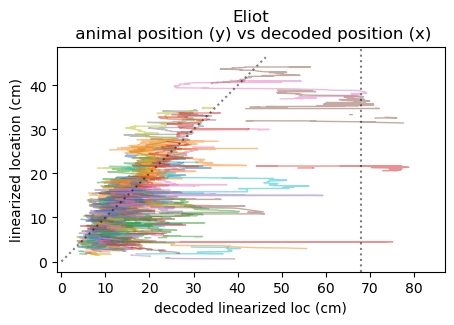

In [103]:
plot_physical_vs_mental_position("Eliot",triggered_positions_abs["Eliot"],triggered_decodes_baseoff["Eliot"])

66


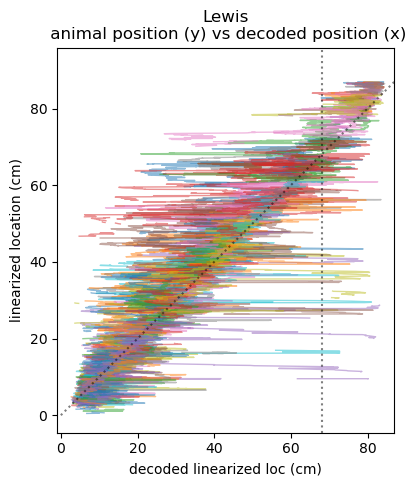

In [104]:
plot_physical_vs_mental_position("Lewis",triggered_positions_abs["Lewis"],triggered_decodes_baseoff["Lewis"])

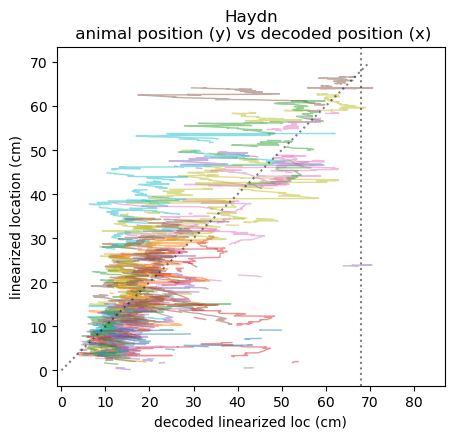

In [105]:
plot_physical_vs_mental_position("Haydn",triggered_positions_abs["Haydn"],triggered_decodes_baseoff["Haydn"])

#### (a2) Pre-stopping

In [ ]:
paramters = {"proportion":0.1, "delta_t_minus":1, "delta_t_plus":0, "max_flag":0}

#### (b) Histogram of the max physical minus CA1 decode difference

In [112]:
def position_minus_decode_histogram(animal, triggered_positions_abs, triggered_decodes_baseoff):
    diff = []
    (positions_abs, decodes_abs) = (triggered_positions_abs[animal], triggered_decodes_baseoff[animal])
        
    for rendition_ind in range(len(positions_abs)):
        position_abs = positions_abs[rendition_ind]
        decode_abs = decodes_abs[rendition_ind]
        if len(position_abs) == len(decode_abs):
            diff.append(np.nanmax(decode_abs - position_abs))
    
    #diff = np.concatenate(diff)

    return diff

In [123]:
animal = "Eliot"
diff = position_minus_decode_histogram(animal, triggered_positions_abs, triggered_decodes_baseoff)

Text(0, 0.5, 'density')

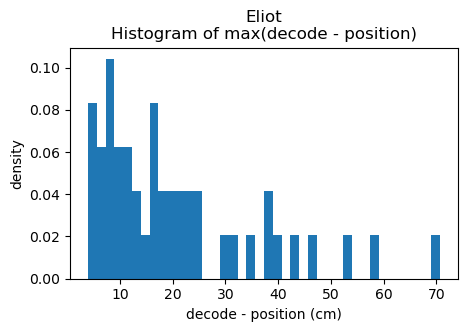

In [126]:
plt.figure(figsize=(5,3))
ax1 = plt.gca()
ax1.hist(diff,bins = 40,weights = np.ones(len(diff))/len(diff));
ax1.set_title(animal + "\nHistogram of max(decode - position)")
ax1.set_xlabel("decode - position (cm)")
ax1.set_ylabel("density")

In [118]:
animal = "Lewis"
diff = position_minus_decode_histogram(animal, triggered_positions_abs, triggered_decodes_baseoff)

Text(0, 0.5, 'density')

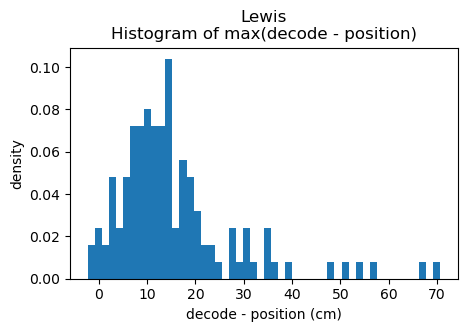

In [121]:
plt.figure(figsize=(5,3))
ax1 = plt.gca()

data = diff
ax1.hist(data,bins = 50,weights = np.ones(len(data))/len(data));
ax1.set_title(animal + "\nHistogram of max(decode - position)")
ax1.set_xlabel("decode - position (cm)")
ax1.set_ylabel("density")

In [127]:
animal = "Haydn"
diff = position_minus_decode_histogram(animal, triggered_positions_abs, triggered_decodes_baseoff)

Text(0, 0.5, 'density')

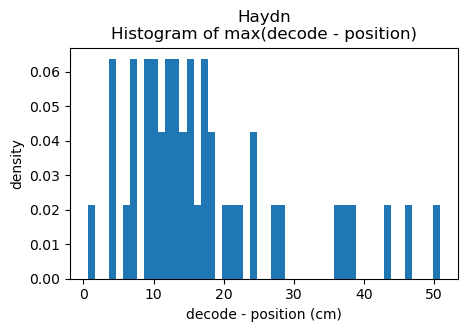

In [130]:
plt.figure(figsize=(5,3))
ax1 = plt.gca()

data = diff
ax1.hist(data,bins = 50,weights = np.ones(len(data))/len(data));
ax1.set_title(animal + "\nHistogram of max(decode - position)")
ax1.set_xlabel("decode - position (cm)")
ax1.set_ylabel("density")

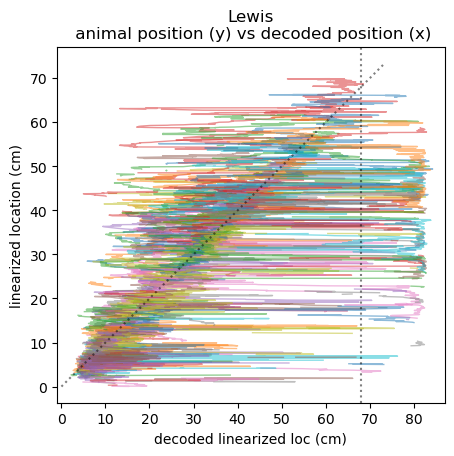

In [543]:
animal = "Lewis"
replay_trials, inds = find_large_position_minus_decode_trials(animal, triggered_trial_info, 
                                            triggered_positions_abs, triggered_decodes_baseoff,cutoff = CUTOFF)
plot_physical_vs_mental_position(animal,
                                 [triggered_positions_abs[animal][xi] for xi in inds],
                                 [triggered_decodes_baseoff[animal][xi] for xi in inds])

#### (c) Mental position minus physical position
This time, we include 1 second before AND after turn around.

In [622]:
triggered_positions = {}
triggered_positions_abs = {}
triggered_decodes = {}
triggered_decodes_abs = {}
triggered_decodes_baseoff = {}

animal = 'Lewis'
dates_to_plot = ['20240109','20240110']
#dates_to_plot = ['20240106','20240107','20240108','20240109']
                 #'20240110','20240113']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions[animal], triggered_positions_abs[animal],
 triggered_decodes[animal], triggered_decodes_baseoff[animal], triggered_decodes_abs[animal],
 triggered_trial_info[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True)

animal = 'Eliot'
#dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
dates_to_plot = ['20221021']
encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions[animal], triggered_positions_abs[animal],
 triggered_decodes[animal], triggered_decodes_baseoff[animal], triggered_decodes_abs[animal],
 triggered_trial_info[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True)

animal = 'Haydn'
dates_to_plot = ['20230606']
encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4arm'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions[animal], triggered_positions_abs[animal],
 triggered_decodes[animal], triggered_decodes_baseoff[animal], triggered_decodes_abs[animal],
 triggered_trial_info[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True)

[15:56:36][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
02_Rev2Session1
pos 1 valid times


[15:56:38][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
04_Rev2Session2
pos 3 valid times


[15:56:39][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


...

currently investigating:
06_Rev3Session3
pos 5 valid times


[15:56:55][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
08_Rev3Session4
pos 7 valid times


[15:56:56][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
10_Rev3Session5
pos 9 valid times


Text(0, 0.5, 'linearized location (cm)')

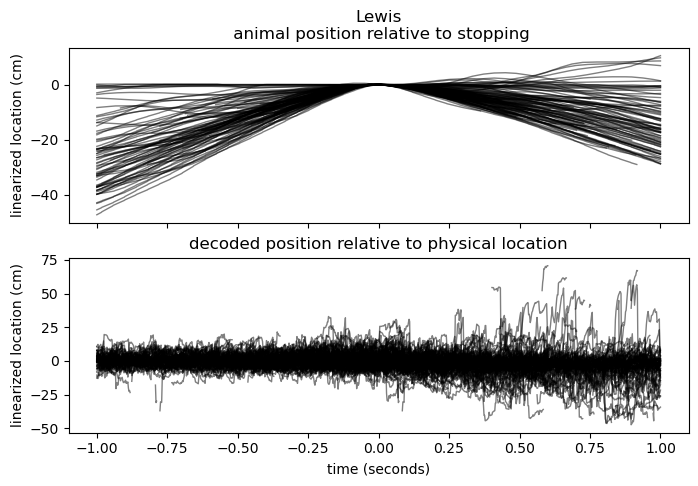

In [624]:
(positions, positions_abs, decodes, decodes_abs) = (triggered_positions[animal], triggered_positions_abs[animal],
     triggered_decodes[animal], triggered_decodes_baseoff[animal])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5),sharex=True)

for position in positions:
    ax1.plot(position, linewidth = 1, alpha = 0.5, color = 'k')

row_ind = 0
for rendition_ind in range(len(positions_abs)):
    position_abs = positions_abs[rendition_ind]
    position = positions[rendition_ind]
    decode_abs = decodes_abs[rendition_ind]
    if len(position_abs) == len(decode_abs):
        ax2.plot(position.index, np.array(decode_abs) - np.array(position_abs), linewidth = 1, alpha = 0.5, color = 'k')
    row_ind = row_ind + 1

ax1.set_title(animal + "\n animal position relative to stopping")
ax2.set_title("decoded position relative to physical location")

ax1.set_ylabel("linearized location (cm)")
ax2.set_xlabel("time (seconds)")
ax2.set_ylabel("linearized location (cm)")

#### (a-control: use nearby trials) Mental position vs physical position
This time, we include 2 second before AND 0.5 seconds after turn around.

In [627]:
triggered_positions = {}
triggered_positions_abs = {}
triggered_decodes = {}
triggered_decodes_baseoff = {}
triggered_decodes_abs = {}

animal = 'Lewis'
dates_to_plot = ['20240109','20240110']
#dates_to_plot = ['20240106','20240107','20240108','20240109']
                 #'20240110','20240113']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions[animal], triggered_positions_abs[animal],
 triggered_decodes[animal], triggered_decodes_baseoff[animal], triggered_decodes_abs[animal],
 triggered_trial_info[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 2,delta_t_plus = 0.5,
                                                                   max_flag = 0, segment_only = True, nearby = 1)

animal = 'Eliot'
#dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
dates_to_plot = ['20221021']
encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions[animal], triggered_positions_abs[animal],
 triggered_decodes[animal], triggered_decodes_baseoff[animal], triggered_decodes_abs[animal],
 triggered_trial_info[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 2,delta_t_plus = 0.5,
                                                                   max_flag = 0, segment_only = True, nearby = 1)

animal = 'Haydn'
dates_to_plot = ['20230606']
encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4arm'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions[animal], triggered_positions_abs[animal],
 triggered_decodes[animal], triggered_decodes_baseoff[animal], triggered_decodes_abs[animal],
 triggered_trial_info[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 2,delta_t_plus = 0.5,
                                                                   max_flag = 0, segment_only = True, nearby = 1)

[16:02:09][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
02_Rev2Session1
pos 1 valid times


[16:02:10][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
04_Rev2Session2
pos 3 valid times


[16:02:12][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


...

currently investigating:
06_Rev3Session3
pos 5 valid times


[16:02:26][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
08_Rev3Session4
pos 7 valid times


[16:02:27][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
10_Rev3Session5
pos 9 valid times


8
9


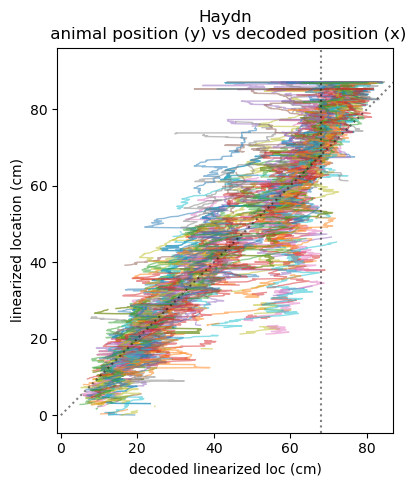

In [629]:
plot_physical_vs_mental_position("Haydn",triggered_positions, triggered_positions_abs,
                                     triggered_decodes, triggered_decodes_baseoff)

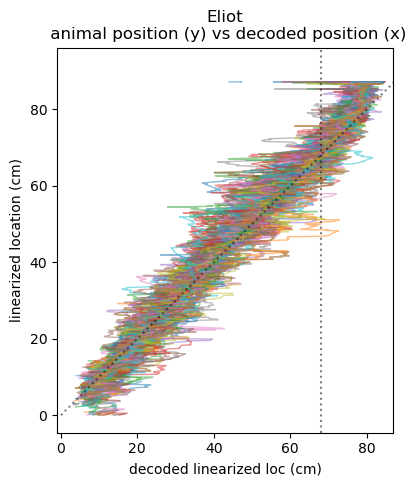

In [630]:
plot_physical_vs_mental_position("Eliot",triggered_positions, triggered_positions_abs,
                                     triggered_decodes, triggered_decodes_baseoff)

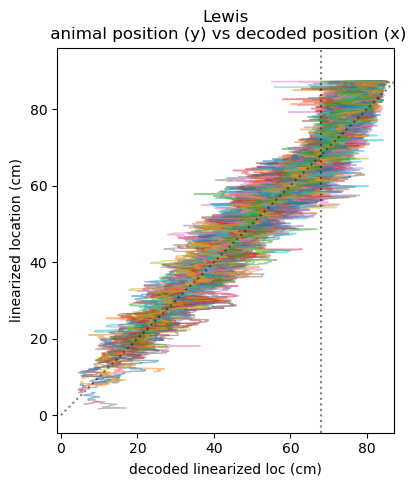

In [631]:
plot_physical_vs_mental_position("Lewis",triggered_positions, triggered_positions_abs,
                                     triggered_decodes, triggered_decodes_baseoff)

#### (c) Find trials with multiple change of minds

In [11]:
triggered_positions1 = {}
triggered_positions_abs1 = {}
triggered_decodes1 = {}
triggered_decodes_abs1 = {}
triggered_decodes_baseoff1 = {}
triggered_trial_info1 = {}

animal = 'Lewis'
dates_to_plot = ['20240109','20240110']
#dates_to_plot = ['20240106','20240107','20240108','20240109']
                 #'20240110','20240113']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions1[animal], triggered_positions_abs1[animal],
 triggered_decodes1[animal], triggered_decodes_baseoff1[animal], triggered_decodes_abs1[animal],
 triggered_trial_info1[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True,
                                                                   multiple_CoM = True, first_CoM = True, last_CoM = False)

animal = 'Eliot'
#dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
dates_to_plot = ['20221021']
encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions1[animal], triggered_positions_abs1[animal],
 triggered_decodes1[animal], triggered_decodes_baseoff1[animal], triggered_decodes_abs1[animal],
 triggered_trial_info1[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True,
                                                                   multiple_CoM = True, first_CoM = True, last_CoM = False)

animal = 'Haydn'
dates_to_plot = ['20230606']
encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4arm'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions1[animal], triggered_positions_abs1[animal],
 triggered_decodes1[animal], triggered_decodes_baseoff1[animal], triggered_decodes_abs1[animal],
 triggered_trial_info1[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True,
                                                                   multiple_CoM = True, first_CoM = True, last_CoM = False)

[14:50:38][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
02_Rev2Session1
pos 1 valid times


[14:50:39][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
04_Rev2Session2
pos 3 valid times


[14:50:39][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


...

currently investigating:
04_Rev3Session2
pos 3 valid times
currently investigating:
06_Rev3Session3
pos 5 valid times


[14:50:43][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
08_Rev3Session4
pos 7 valid times


[14:50:43][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
10_Rev3Session5
pos 9 valid times


In [12]:
triggered_positions2 = {}
triggered_positions_abs2 = {}
triggered_decodes2 = {}
triggered_decodes_abs2 = {}
triggered_decodes_baseoff2 = {}
triggered_trial_info2 = {}

animal = 'Lewis'
dates_to_plot = ['20240109','20240110']
#dates_to_plot = ['20240106','20240107','20240108','20240109']
                 #'20240110','20240113']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions2[animal], triggered_positions_abs2[animal],
 triggered_decodes2[animal], triggered_decodes_baseoff2[animal], triggered_decodes_abs2[animal],
 triggered_trial_info2[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True,
                                                                   multiple_CoM = True, first_CoM = False, last_CoM = True)

animal = 'Eliot'
#dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
dates_to_plot = ['20221021']
encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions2[animal], triggered_positions_abs2[animal],
 triggered_decodes2[animal], triggered_decodes_baseoff2[animal], triggered_decodes_abs2[animal],
 triggered_trial_info2[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True,
                                                                   multiple_CoM = True, first_CoM = False, last_CoM = True)

animal = 'Haydn'
dates_to_plot = ['20230606']
encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4arm'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions2[animal], triggered_positions_abs2[animal],
 triggered_decodes2[animal], triggered_decodes_baseoff2[animal], triggered_decodes_abs2[animal],
 triggered_trial_info2[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True,
                                                                   multiple_CoM = True, first_CoM = False, last_CoM = True)

[14:52:07][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
02_Rev2Session1
pos 1 valid times


[14:52:07][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
04_Rev2Session2
pos 3 valid times


[14:52:07][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


...

currently investigating:
04_Rev3Session2
pos 3 valid times
currently investigating:
06_Rev3Session3
pos 5 valid times


[14:52:11][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
08_Rev3Session4
pos 7 valid times


[14:52:12][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
10_Rev3Session5
pos 9 valid times


In [16]:
triggered_positions3 = {}
triggered_positions_abs3 = {}
triggered_decodes3 = {}
triggered_decodes_abs3 = {}
triggered_decodes_baseoff3 = {}
triggered_trial_info3 = {}

animal = 'Lewis'
dates_to_plot = ['20240109','20240110']
#dates_to_plot = ['20240106','20240107','20240108','20240109']
                 #'20240110','20240113']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions3[animal], triggered_positions_abs3[animal],
 triggered_decodes3[animal], triggered_decodes_baseoff3[animal], triggered_decodes_abs3[animal],
 triggered_trial_info3[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True,
                                                                   multiple_CoM = False,  single_CoM = True,
                                                                    first_CoM = False, last_CoM = False)

animal = 'Eliot'
#dates_to_plot = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
dates_to_plot = ['20221021']
encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions3[animal], triggered_positions_abs3[animal],
 triggered_decodes3[animal], triggered_decodes_baseoff3[animal], triggered_decodes_abs3[animal],
 triggered_trial_info3[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True,
                                                                   multiple_CoM = False,  single_CoM = True,
                                                                    first_CoM = False, last_CoM = False)

animal = 'Haydn'
dates_to_plot = ['20230606']
encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4arm'
datafolder = f'/cumulus/shijie/behavior_pilot/Batch1/{animal}'

(triggered_positions3[animal], triggered_positions_abs3[animal],
 triggered_decodes3[animal], triggered_decodes_baseoff3[animal], triggered_decodes_abs3[animal],
 triggered_trial_info3[animal]) = find_triggered_animal(animal,dates_to_plot,
                                                                   delta_t_minus = 1,delta_t_plus = 1,
                                                                   max_flag = 0, segment_only = True,
                                                                   multiple_CoM = False,  single_CoM = True,
                                                                    first_CoM = False, last_CoM = False)

[14:59:47][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:59:47][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:59:48][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
02_Rev2Session1
pos 1 valid times


[14:59:48][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
04_Rev2Session2
pos 3 valid times


[14:59:49][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


...

currently investigating:
06_Rev3Session3
pos 5 valid times


[15:00:01][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
08_Rev3Session4
pos 7 valid times


[15:00:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.


currently investigating:
10_Rev3Session5
pos 9 valid times


time
1.704829e+09    3.797803
1.704829e+09    3.854218
1.704829e+09    3.910634
1.704829e+09    3.967049
1.704829e+09    4.023465
                  ...   
1.704829e+09    5.189019
1.704829e+09    5.153081
1.704829e+09    5.117144
1.704829e+09    5.081206
1.704829e+09    5.045269
Length: 1001, dtype: float64

In [44]:
length_by_ind

array([40, 22, 36,  0, 39, 29, 38, 20,  9, 17, 37, 53, 24, 28,  7, 21, 42,
       18,  8, 33, 19, 25, 51, 55, 45,  4, 12, 52, 47,  5, 46,  1,  2, 50,
       49, 48, 44, 43,  3, 41, 16,  6, 10, 11, 35, 34, 32, 31, 30, 13, 14,
       54, 26, 15, 23, 27])

In [48]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

Text(0.5, 1.0, 'decoded - physical, single C-o-M')

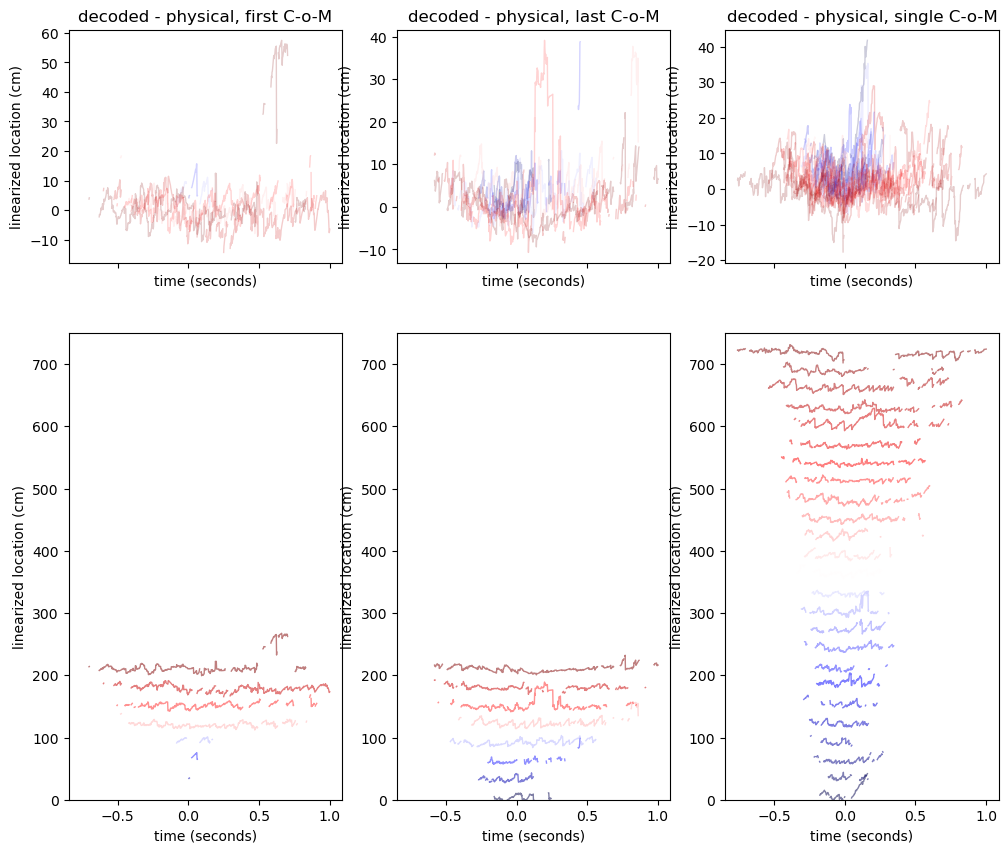

In [79]:
animal = "Eliot"


cmap = cm.seismic


fig, axes = plt.subplots(2, 3, figsize=(12, 10),sharex=True,gridspec_kw={"height_ratios": [1,2]})

for version in range(3):
    if version == 0:
        (positions, positions_abs, decodes, decodes_abs) = (triggered_positions1[animal], triggered_positions_abs1[animal],
             triggered_decodes1[animal], triggered_decodes_baseoff1[animal])
    elif version == 1:
        (positions, positions_abs, decodes, decodes_abs) = (triggered_positions2[animal], triggered_positions_abs2[animal],
             triggered_decodes2[animal], triggered_decodes_baseoff2[animal])
    elif version == 2:
        (positions, positions_abs, decodes, decodes_abs) = (triggered_positions3[animal], triggered_positions_abs3[animal],
             triggered_decodes3[animal], triggered_decodes_baseoff3[animal])

    # sort by trace length
    length = [len(tt) for tt in positions]
    ind_by_length = np.argsort(length)
    norm = Normalize(vmin=0, vmax=len(ind_by_length) - 1)
    
    #for position in positions:
    #    axes[0,version].plot(position, linewidth = 1, alpha = 0.5, color = 'k')

    row_ind = 0
    for rendition_ind in ind_by_length:
        
        position_abs = positions_abs[rendition_ind]
        position = positions[rendition_ind]
        decode_abs = decodes_abs[rendition_ind]
        if len(position_abs) == len(decode_abs):
            axes[1,version].plot(position.index, (np.array(decode_abs) - np.array(position_abs) + row_ind*30),
                                 linewidth = 1, alpha = 0.5, color = cmap(norm(row_ind)))
        row_ind = row_ind + 1
        
    row_ind = 0
    
    for rendition_ind in ind_by_length:
        position_abs = positions_abs[rendition_ind]
        position = positions[rendition_ind]
        decode_abs = decodes_abs[rendition_ind]
        if len(position_abs) == len(decode_abs):
            axes[0,version].plot(position.index, (np.array(decode_abs) - np.array(position_abs)),
                                 linewidth = 1, alpha = 0.2, color = cmap(norm(row_ind)))
        row_ind = row_ind + 1
    
    
    #axes[0version].set_ylabel("linearized location (cm)")
    axes[1,version].set_xlabel("time (seconds)")
    axes[1,version].set_ylabel("linearized location (cm)")

    axes[0,version].set_xlabel("time (seconds)")
    axes[0,version].set_ylabel("linearized location (cm)")
    axes[1,version].set_ylim([0, len(triggered_decodes3[animal]) * 30])

axes[0,0].set_title(animal + "\n animal posi relative to stop, first C-o-M")
axes[0,0].set_title("decoded - physical, first C-o-M")
axes[0,1].set_title(animal + "\n animal position relative to stopping, last C-o-M")
axes[0,1].set_title("decoded - physical, last C-o-M")
axes[0,2].set_title(animal + "\n animal position relative to stopping, single C-o-M")
axes[0,2].set_title("decoded - physical, single C-o-M")



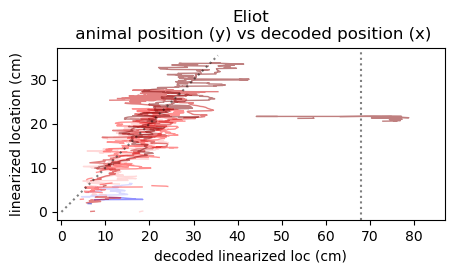

In [81]:
animal = "Eliot"
plot_physical_vs_mental_position(animal, triggered_positions_abs1[animal], triggered_decodes_baseoff1[animal])

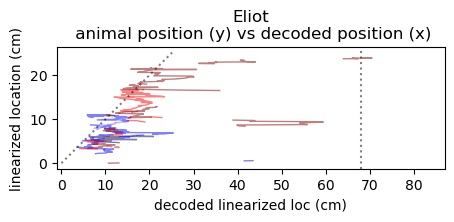

In [77]:
animal = "Haydn"
plot_physical_vs_mental_position("Eliot", triggered_positions_abs2[animal], triggered_decodes_baseoff2[animal])

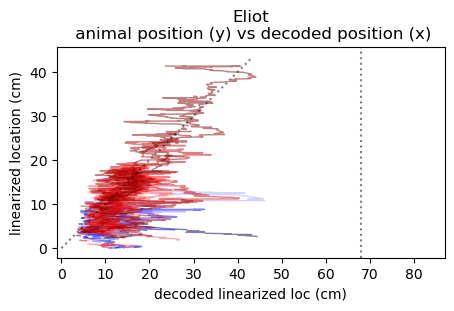

In [82]:
animal = "Eliot"
plot_physical_vs_mental_position(animal, triggered_positions_abs3[animal], triggered_decodes_baseoff3[animal])

## End here